# A04 — MNIST FULL
## NumPy From Scratch → PyTorch Baseline/Improved → TensorFlow Baseline/Improved

Notebook này làm **trọn flow MNIST** cho Assignment 04 theo cách chúng ta đã thống nhất:

```text
MNIST
│
├── 1. Load + EDA + preprocessing
│
├── 2. NumPy FROM SCRATCH
│   ├── Conv2D forward/backward
│   ├── ReLU forward/backward
│   ├── MaxPool forward/backward
│   ├── Flatten
│   ├── Dense forward/backward
│   ├── Softmax Cross Entropy
│   ├── SGD update
│   └── train + evaluate
│
├── 3. PyTorch
│   ├── Baseline CNN
│   ├── Improved CNN
│   └── train + evaluate + compare
│
├── 4. TensorFlow/Keras
│   ├── Baseline CNN
│   ├── Improved CNN
│   └── train + evaluate + compare
│
└── 5. Tổng hợp kết quả
    ├── Accuracy / Precision / Recall / F1
    ├── Loss
    ├── Parameters
    ├── Training time
    ├── Confusion matrix
    └── Prediction sai
```

### Ý nghĩa của `Baseline` và `Improved`

- **Baseline CNN**: model CNN cơ bản dùng làm mốc.
- **Improved CNN**: model được cải tiến từ Baseline, ví dụ thêm `BatchNorm`, thêm block convolution, `Dropout`.
- Sau khi train cả hai, ta mới có cơ sở nói cải tiến có hiệu quả hay không.

> **Lưu ý về NumPy Scratch:** code là đầy đủ cả forward + backward + update weight.  
> Mặc định notebook dùng một **subset** cho phần NumPy để thời gian chạy hợp lý trên CPU.  
> Muốn train toàn bộ MNIST bằng NumPy, đặt `FAST_SCRATCH = False`.

# 0. Cài thư viện

Nếu môi trường chưa đủ thư viện, chạy trong terminal:

```bash
pip install numpy pandas matplotlib scikit-learn torch torchvision tensorflow jupyter ipykernel
```

Nếu `TensorFlow` không cài được trong environment hiện tại, nên tạo một environment Python riêng tương thích rồi chọn kernel đó cho notebook.

In [1]:
# Có thể bỏ comment và chạy ngay trong notebook nếu cần:
# %pip install numpy pandas matplotlib scikit-learn torch torchvision tensorflow

# 1. Import thư viện và cấu hình chung

In [2]:
from pathlib import Path
import time
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.5.3
Pandas: 3.0.5


## 1.1. Tự tìm file MNIST trong project

Notebook sẽ đi ngược dần từ thư mục hiện tại để tìm:

```text
data/MNIST/mnist_train.csv
data/MNIST/mnist_test.csv
```

Như vậy notebook vẫn chạy được nếu bạn đặt nó ở `a04/notebook/MNist/`.

In [3]:
def find_mnist_dir():
    current = Path.cwd().resolve()

    candidates = []
    for base in [current, *current.parents]:
        candidates.extend(
            [
                base / "data" / "MNIST",
                base / "MNIST",
                base / "data" / "mnist",
            ]
        )

    for folder in candidates:
        train_path = folder / "mnist_train.csv"
        test_path = folder / "mnist_test.csv"

        if train_path.exists() and test_path.exists():
            return folder

    raise FileNotFoundError(
        "Không tìm thấy mnist_train.csv và mnist_test.csv. "
        "Hãy kiểm tra thư mục data/MNIST hoặc sửa đường dẫn thủ công."
    )


MNIST_DIR = find_mnist_dir()

TRAIN_CSV = MNIST_DIR / "mnist_train.csv"
TEST_CSV = MNIST_DIR / "mnist_test.csv"

print("MNIST_DIR :", MNIST_DIR)
print("TRAIN_CSV :", TRAIN_CSV)
print("TEST_CSV  :", TEST_CSV)

MNIST_DIR : C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\a04\data\MNIST
TRAIN_CSV : C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\a04\data\MNIST\mnist_train.csv
TEST_CSV  : C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\a04\data\MNIST\mnist_test.csv


# 2. Load dữ liệu MNIST

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train dataframe:", train_df.shape)
print("Test dataframe :", test_df.shape)

display(train_df.head())

Train dataframe: (60000, 785)
Test dataframe : (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2.1. Xác định label và pixel

MNIST CSV thường có:

- `label`: chữ số thật từ `0` đến `9`.
- 784 pixel = `28 × 28`.
- mỗi pixel thường có giá trị `0 → 255`.

In [5]:
LABEL_COL = "label" if "label" in train_df.columns else train_df.columns[0]

pixel_cols = [col for col in train_df.columns if col != LABEL_COL]

print("Label column :", LABEL_COL)
print("Pixel columns:", len(pixel_cols))
print("Classes      :", sorted(train_df[LABEL_COL].unique().tolist()))

assert len(pixel_cols) == 784, f"Kỳ vọng 784 pixel nhưng dataset có {len(pixel_cols)} cột pixel."

assert train_df[LABEL_COL].between(0, 9).all()
assert test_df[LABEL_COL].between(0, 9).all()

Label column : label
Pixel columns: 784
Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# 3. EDA — khám phá dữ liệu

## 3.1. Phân bố class

,count
label,
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851


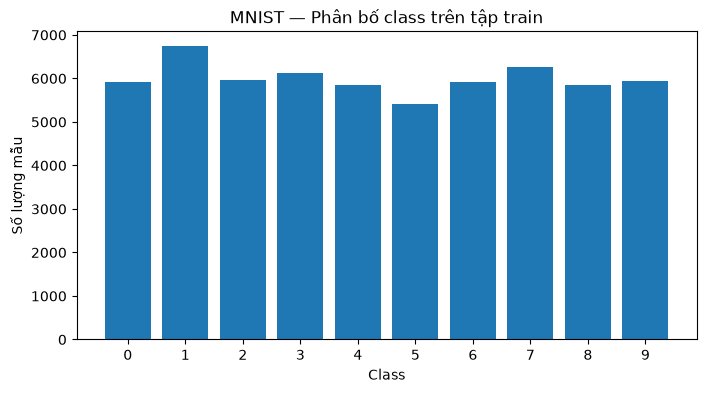

In [6]:
class_counts = train_df[LABEL_COL].value_counts().sort_index()

display(class_counts.rename("count").to_frame())

plt.figure(figsize=(8, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class")
plt.ylabel("Số lượng mẫu")
plt.title("MNIST — Phân bố class trên tập train")
plt.show()

## 3.2. Hiển thị một số ảnh

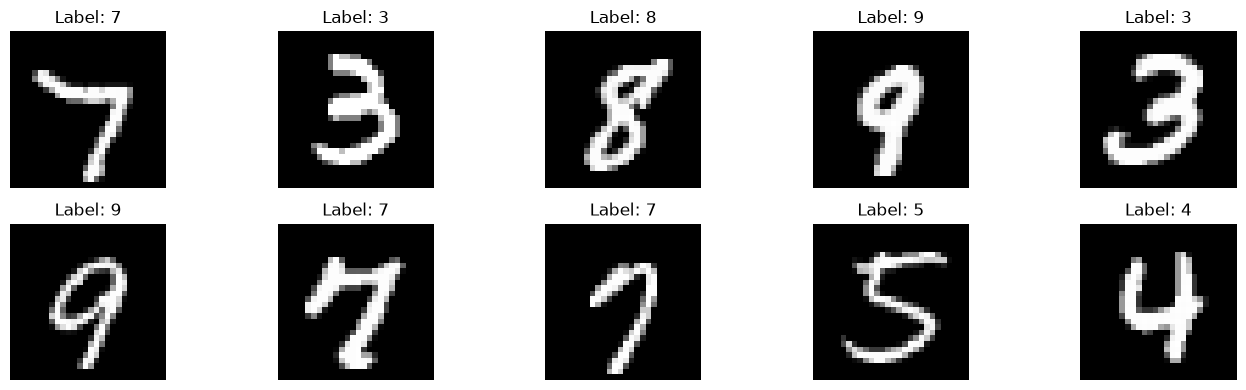

In [7]:
def show_samples(df, n=10, random_state=SEED):
    sample_df = df.sample(n=n, random_state=random_state)

    plt.figure(figsize=(14, 4))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        image = row[pixel_cols].to_numpy(dtype=np.float32).reshape(28, 28)
        label = int(row[LABEL_COL])

        plt.subplot(2, 5, i)
        plt.imshow(image, cmap="gray")
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_df)

# 4. Tiền xử lý và chia Train / Validation / Test

In [8]:
# -----------------------------
# Tách feature / label
# -----------------------------
X_full = train_df[pixel_cols].to_numpy(dtype=np.float32)
y_full = train_df[LABEL_COL].to_numpy(dtype=np.int64)

X_test = test_df[pixel_cols].to_numpy(dtype=np.float32)
y_test = test_df[LABEL_COL].to_numpy(dtype=np.int64)

# -----------------------------
# Normalize pixel: [0,255] -> [0,1]
# -----------------------------
X_full /= 255.0
X_test /= 255.0

# -----------------------------
# PyTorch / NumPy Scratch dùng NCHW:
# (N, channel, height, width)
# -----------------------------
X_full = X_full.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

# -----------------------------
# Tách validation từ tập train
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_full,
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (48000, 1, 28, 28) (48000,)
Val  : (12000, 1, 28, 28) (12000,)
Test : (10000, 1, 28, 28) (10000,)


### Ý nghĩa

- **Train**: dùng để cập nhật weight.
- **Validation**: dùng theo dõi quá trình train và lựa chọn/cải tiến kiến trúc.
- **Test**: dùng đánh giá cuối cùng.

Tất cả implementation phía dưới dùng cùng split này để việc so sánh công bằng hơn.

# PHẦN A — CNN FROM SCRATCH BẰNG NUMPY

## 5. Mục tiêu phần Scratch

Ta **không gọi**:

```python
torch.nn.Conv2d
tf.keras.layers.Conv2D
```

Mà tự viết:

```text
Conv2D
→ ReLU
→ MaxPool
→ Conv2D
→ ReLU
→ Flatten
→ Dense
→ Softmax Cross Entropy
```

và tự thực hiện:

```text
forward → loss → backward → update weight
```

Đây mới là một training pipeline CNN from scratch thực sự.

## 5.1. Helper: `im2col` / `col2im`

In [9]:
def im2col(x, kernel_h, kernel_w, stride=1, padding=0):
    """
    Chuyển các local image patch thành từng dòng của ma trận.

    Input:
        x: (N, C, H, W)

    Output:
        cols:
        (N * out_h * out_w, C * kernel_h * kernel_w)

    Tác dụng:
        biến convolution thành phép nhân ma trận,
        nhanh hơn rất nhiều so với 6 vòng for thuần Python.
    """
    N, C, H, W = x.shape

    out_h = (H + 2 * padding - kernel_h) // stride + 1
    out_w = (W + 2 * padding - kernel_w) // stride + 1

    x_padded = np.pad(
        x,
        (
            (0, 0),
            (0, 0),
            (padding, padding),
            (padding, padding),
        ),
        mode="constant",
    )

    cols = np.empty(
        (N, out_h, out_w, C, kernel_h, kernel_w),
        dtype=x.dtype,
    )

    for kh in range(kernel_h):
        h_slice = slice(kh, kh + stride * out_h, stride)

        for kw in range(kernel_w):
            w_slice = slice(kw, kw + stride * out_w, stride)

            patch = x_padded[:, :, h_slice, w_slice]
            cols[:, :, :, :, kh, kw] = patch.transpose(0, 2, 3, 1)

    cols = cols.reshape(
        N * out_h * out_w,
        C * kernel_h * kernel_w,
    )

    return cols, out_h, out_w


def col2im(
    cols,
    x_shape,
    kernel_h,
    kernel_w,
    stride=1,
    padding=0,
):
    """
    Phép ngược của im2col.

    Dùng trong backward để đưa gradient từ ma trận patch
    về lại shape ảnh gốc.
    """
    N, C, H, W = x_shape

    out_h = (H + 2 * padding - kernel_h) // stride + 1
    out_w = (W + 2 * padding - kernel_w) // stride + 1

    cols_reshaped = cols.reshape(
        N,
        out_h,
        out_w,
        C,
        kernel_h,
        kernel_w,
    )

    x_padded = np.zeros(
        (N, C, H + 2 * padding, W + 2 * padding),
        dtype=cols.dtype,
    )

    for kh in range(kernel_h):
        h_slice = slice(kh, kh + stride * out_h, stride)

        for kw in range(kernel_w):
            w_slice = slice(kw, kw + stride * out_w, stride)

            grad_patch = cols_reshaped[:, :, :, :, kh, kw]
            grad_patch = grad_patch.transpose(0, 3, 1, 2)

            x_padded[:, :, h_slice, w_slice] += grad_patch

    if padding == 0:
        return x_padded

    return x_padded[:, :, padding:-padding, padding:-padding]

## 5.2. `Conv2D` tự viết

In [10]:
class Conv2D:
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # He initialization phù hợp ReLU.
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))

        self.W = (
            np.random.randn(
                out_channels,
                in_channels,
                kernel_size,
                kernel_size,
            ).astype(np.float32)
            * scale
        )

        self.b = np.zeros(out_channels, dtype=np.float32)

        self.dW = None
        self.db = None
        self.cache = None

    def forward(self, x):
        cols, out_h, out_w = im2col(
            x,
            self.kernel_size,
            self.kernel_size,
            stride=self.stride,
            padding=self.padding,
        )

        W_col = self.W.reshape(self.out_channels, -1)

        out = cols @ W_col.T + self.b

        out = out.reshape(
            x.shape[0],
            out_h,
            out_w,
            self.out_channels,
        ).transpose(0, 3, 1, 2)

        self.cache = (x.shape, cols)

        return out

    def backward(self, dout):
        x_shape, cols = self.cache

        # N,F,H,W -> N,H,W,F -> 2D
        dout_2d = dout.transpose(0, 2, 3, 1).reshape(
            -1,
            self.out_channels,
        )

        # Gradient kernel
        self.dW = (dout_2d.T @ cols).reshape(self.W.shape)

        # Gradient bias
        self.db = dout_2d.sum(axis=0)

        # Gradient input
        W_col = self.W.reshape(self.out_channels, -1)
        dcols = dout_2d @ W_col

        dx = col2im(
            dcols,
            x_shape,
            self.kernel_size,
            self.kernel_size,
            stride=self.stride,
            padding=self.padding,
        )

        return dx

    def step(self, learning_rate):
        self.W -= learning_rate * self.dW
        self.b -= learning_rate * self.db

    def param_count(self):
        return self.W.size + self.b.size

## 5.3. `ReLU` tự viết

In [11]:
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = x > 0
        return np.maximum(x, 0)

    def backward(self, dout):
        return dout * self.mask

    def step(self, learning_rate):
        pass

    def param_count(self):
        return 0

## 5.4. `MaxPool2D` tự viết

In [12]:
class MaxPool2D:
    """
    Bản educational:
    pool_size = stride = 2.

    Input:
        (N,C,H,W)

    Output:
        (N,C,H/2,W/2)
    """

    def __init__(self, pool_size=2):
        self.pool_size = pool_size
        self.cache = None

    def forward(self, x):
        N, C, H, W = x.shape
        p = self.pool_size

        assert H % p == 0 and W % p == 0

        out_h = H // p
        out_w = W // p

        # Gom mỗi cửa sổ p x p thành một vector.
        windows = x.reshape(
            N,
            C,
            out_h,
            p,
            out_w,
            p,
        )

        windows = windows.transpose(0, 1, 2, 4, 3, 5).reshape(
            N,
            C,
            out_h,
            out_w,
            p * p,
        )

        argmax = np.argmax(windows, axis=-1)
        out = np.max(windows, axis=-1)

        self.cache = (x.shape, argmax)

        return out

    def backward(self, dout):
        x_shape, argmax = self.cache
        N, C, H, W = x_shape
        p = self.pool_size

        out_h = H // p
        out_w = W // p

        grad_windows = np.zeros(
            (N, C, out_h, out_w, p * p),
            dtype=dout.dtype,
        )

        np.put_along_axis(
            grad_windows,
            argmax[..., None],
            dout[..., None],
            axis=-1,
        )

        grad_windows = grad_windows.reshape(
            N,
            C,
            out_h,
            out_w,
            p,
            p,
        )

        dx = grad_windows.transpose(0, 1, 2, 4, 3, 5).reshape(
            N,
            C,
            H,
            W,
        )

        return dx

    def step(self, learning_rate):
        pass

    def param_count(self):
        return 0

## 5.5. `Flatten` và `Dense` tự viết

In [13]:
class Flatten:
    def __init__(self):
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.input_shape)

    def step(self, learning_rate):
        pass

    def param_count(self):
        return 0


class Dense:
    def __init__(self, in_features, out_features):
        scale = np.sqrt(2.0 / in_features)

        self.W = np.random.randn(in_features, out_features).astype(np.float32) * scale

        self.b = np.zeros(out_features, dtype=np.float32)

        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)

        dx = dout @ self.W.T
        return dx

    def step(self, learning_rate):
        self.W -= learning_rate * self.dW
        self.b -= learning_rate * self.db

    def param_count(self):
        return self.W.size + self.b.size

## 5.6. Softmax + Cross Entropy tự viết

In [14]:
class SoftmaxCrossEntropy:
    def __init__(self):
        self.probs = None
        self.labels = None

    def forward(self, logits, labels):
        # Stable softmax: trừ max để tránh exp quá lớn.
        shifted = logits - logits.max(
            axis=1,
            keepdims=True,
        )

        exp_values = np.exp(shifted)

        probs = exp_values / exp_values.sum(
            axis=1,
            keepdims=True,
        )

        self.probs = probs
        self.labels = labels

        n = logits.shape[0]

        loss = -np.log(probs[np.arange(n), labels] + 1e-12).mean()

        return float(loss)

    def backward(self):
        grad = self.probs.copy()
        n = grad.shape[0]

        grad[np.arange(n), self.labels] -= 1
        grad /= n

        return grad

## 5.7. Ghép thành `ScratchCNN`

In [15]:
class ScratchCNN:
    """
    CNN nhỏ tự viết bằng NumPy:

    Input
      -> Conv(1->8)
      -> ReLU
      -> MaxPool(2)
      -> Conv(8->16)
      -> ReLU
      -> Flatten
      -> Dense(16*14*14 -> 10)
    """

    def __init__(self):
        self.layers = [
            Conv2D(
                in_channels=1,
                out_channels=8,
                kernel_size=3,
                padding=1,
            ),
            ReLU(),
            MaxPool2D(pool_size=2),
            Conv2D(
                in_channels=8,
                out_channels=16,
                kernel_size=3,
                padding=1,
            ),
            ReLU(),
            Flatten(),
            Dense(
                in_features=16 * 14 * 14,
                out_features=10,
            ),
        ]

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)

        return x

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)

    def step(self, learning_rate):
        for layer in self.layers:
            layer.step(learning_rate)

    def param_count(self):
        return sum(layer.param_count() for layer in self.layers)

## 5.8. Kiểm tra shape Scratch CNN

In [16]:
scratch_model = ScratchCNN()

dummy = X_train[:4]

print("Input:", dummy.shape)

x = dummy

for i, layer in enumerate(scratch_model.layers):
    x = layer.forward(x)

    print(f"{i:02d} {layer.__class__.__name__:12s} -> {x.shape}")

print("Scratch trainable parameters:", f"{scratch_model.param_count():,}")

Input: (4, 1, 28, 28)
00 Conv2D       -> (4, 8, 28, 28)
01 ReLU         -> (4, 8, 28, 28)
02 MaxPool2D    -> (4, 8, 14, 14)
03 Conv2D       -> (4, 16, 14, 14)
04 ReLU         -> (4, 16, 14, 14)
05 Flatten      -> (4, 3136)
06 Dense        -> (4, 10)
Scratch trainable parameters: 32,618


## 5.9. Chuẩn bị subset cho Scratch

Naive/educational NumPy vẫn chậm hơn framework đã tối ưu.

Mặc định:

```python
FAST_SCRATCH = True
```

để train nhanh trên subset.

Muốn chạy toàn bộ:

```python
FAST_SCRATCH = False
```

In [17]:
FAST_SCRATCH = True

if FAST_SCRATCH:
    SCRATCH_TRAIN_LIMIT = min(5_000, len(X_train))
    SCRATCH_VAL_LIMIT = min(1_000, len(X_val))
    SCRATCH_TEST_LIMIT = min(2_000, len(X_test))

    X_train_s = X_train[:SCRATCH_TRAIN_LIMIT]
    y_train_s = y_train[:SCRATCH_TRAIN_LIMIT]

    X_val_s = X_val[:SCRATCH_VAL_LIMIT]
    y_val_s = y_val[:SCRATCH_VAL_LIMIT]

    X_test_s = X_test[:SCRATCH_TEST_LIMIT]
    y_test_s = y_test[:SCRATCH_TEST_LIMIT]
else:
    X_train_s, y_train_s = X_train, y_train
    X_val_s, y_val_s = X_val, y_val
    X_test_s, y_test_s = X_test, y_test


print("Scratch train:", X_train_s.shape)
print("Scratch val  :", X_val_s.shape)
print("Scratch test :", X_test_s.shape)

Scratch train: (5000, 1, 28, 28)
Scratch val  : (1000, 1, 28, 28)
Scratch test : (2000, 1, 28, 28)


## 5.10. Training loop Scratch

In [18]:
def iterate_minibatches(X, y, batch_size, shuffle=True):
    indices = np.arange(len(X))

    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, len(X), batch_size):
        batch_idx = indices[start : start + batch_size]

        yield X[batch_idx], y[batch_idx]


def evaluate_scratch(model, X, y, batch_size=128):
    all_true = []
    all_pred = []

    total_loss = 0.0
    total_count = 0

    criterion = SoftmaxCrossEntropy()

    for xb, yb in iterate_minibatches(
        X,
        y,
        batch_size=batch_size,
        shuffle=False,
    ):
        logits = model.forward(xb)
        loss = criterion.forward(logits, yb)

        preds = logits.argmax(axis=1)

        total_loss += loss * len(xb)
        total_count += len(xb)

        all_true.extend(yb.tolist())
        all_pred.extend(preds.tolist())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true,
        all_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(all_true, all_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": all_true,
        "y_pred": all_pred,
    }


def fit_scratch(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=3,
    batch_size=64,
    learning_rate=0.01,
):
    criterion = SoftmaxCrossEntropy()

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in iterate_minibatches(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True,
        ):
            # 1. Forward
            logits = model.forward(xb)

            # 2. Loss
            loss = criterion.forward(logits, yb)

            # 3. Gradient từ loss
            dlogits = criterion.backward()

            # 4. Backprop qua toàn bộ CNN
            model.backward(dlogits)

            # 5. Update weight
            model.step(learning_rate)

            preds = logits.argmax(axis=1)

            running_loss += loss * len(xb)
            correct += (preds == yb).sum()
            total += len(xb)

        train_loss = running_loss / total
        train_acc = correct / total

        val_result = evaluate_scratch(
            model,
            X_val,
            y_val,
            batch_size=batch_size,
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_result["loss"])
        history["val_accuracy"].append(val_result["accuracy"])

        print(
            f"[Scratch] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_result['loss']:.4f} | "
            f"val_acc={val_result['accuracy']:.4f}"
        )

    elapsed = time.perf_counter() - start_time

    return history, elapsed

## 5.11. Train Scratch CNN

In [19]:
np.random.seed(SEED)

scratch_model = ScratchCNN()

SCRATCH_EPOCHS = 3
SCRATCH_BATCH_SIZE = 64
SCRATCH_LR = 0.01

scratch_history, scratch_train_time = fit_scratch(
    scratch_model,
    X_train_s,
    y_train_s,
    X_val_s,
    y_val_s,
    epochs=SCRATCH_EPOCHS,
    batch_size=SCRATCH_BATCH_SIZE,
    learning_rate=SCRATCH_LR,
)

print(f"Scratch training time: {scratch_train_time:.2f} seconds")

[Scratch] Epoch 01/3 | train_loss=1.2179 | train_acc=0.6512 | val_loss=0.7635 | val_acc=0.7600
[Scratch] Epoch 02/3 | train_loss=0.5340 | train_acc=0.8434 | val_loss=0.4825 | val_acc=0.8730
[Scratch] Epoch 03/3 | train_loss=0.4136 | train_acc=0.8752 | val_loss=0.5177 | val_acc=0.8480
Scratch training time: 27.30 seconds


## 5.12. Đánh giá Scratch CNN

In [20]:
scratch_test = evaluate_scratch(
    scratch_model,
    X_test_s,
    y_test_s,
    batch_size=128,
)

print("NUMPY SCRATCH TEST")
print("-" * 50)
print(f"Loss      : {scratch_test['loss']:.4f}")
print(f"Accuracy  : {scratch_test['accuracy']:.4f}")
print(f"Precision : {scratch_test['precision']:.4f}")
print(f"Recall    : {scratch_test['recall']:.4f}")
print(f"F1        : {scratch_test['f1']:.4f}")
print(f"Params    : {scratch_model.param_count():,}")
print(f"Train time: {scratch_train_time:.2f}s")

NUMPY SCRATCH TEST
--------------------------------------------------
Loss      : 0.5226
Accuracy  : 0.8275
Precision : 0.8445
Recall    : 0.8291
F1        : 0.8283
Params    : 32,618
Train time: 27.30s


## 5.13. Learning curve Scratch

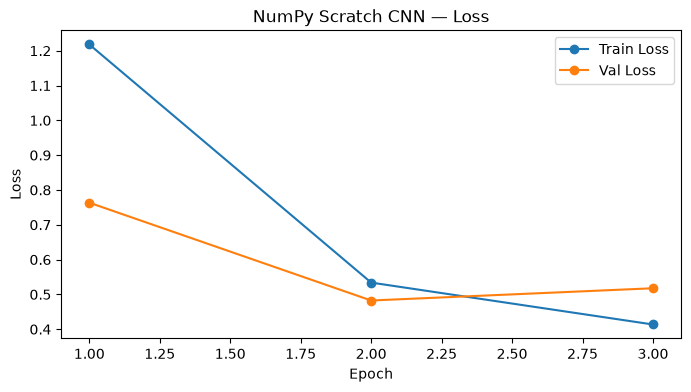

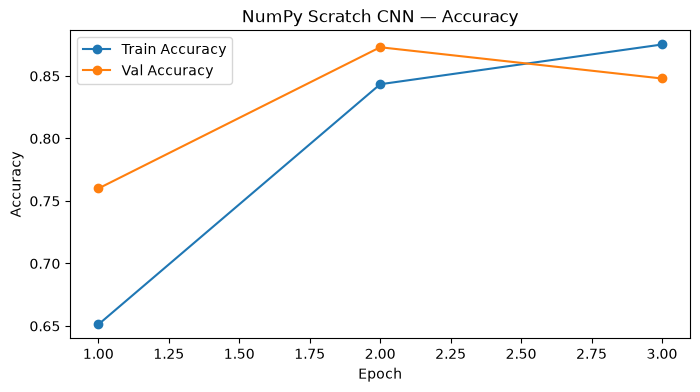

In [21]:
def plot_history_dict(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss",
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Val Loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Train Accuracy",
    )
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Val Accuracy",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.show()


plot_history_dict(
    scratch_history,
    "NumPy Scratch CNN",
)

# PHẦN B — PYTORCH

## 6. Import PyTorch và kiểm tra device

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.14.0+cpu
Device : cpu


## 6.1. Dataset và DataLoader

In [23]:
class MNISTArrayDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32,
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


TORCH_BATCH_SIZE = 128

torch_train_dataset = MNISTArrayDataset(
    X_train,
    y_train,
)

torch_val_dataset = MNISTArrayDataset(
    X_val,
    y_val,
)

torch_test_dataset = MNISTArrayDataset(
    X_test,
    y_test,
)

torch_train_loader = DataLoader(
    torch_train_dataset,
    batch_size=TORCH_BATCH_SIZE,
    shuffle=True,
)

torch_val_loader = DataLoader(
    torch_val_dataset,
    batch_size=TORCH_BATCH_SIZE,
    shuffle=False,
)

torch_test_loader = DataLoader(
    torch_test_dataset,
    batch_size=TORCH_BATCH_SIZE,
    shuffle=False,
)

images, labels = next(iter(torch_train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([128, 1, 28, 28])
Labels: torch.Size([128])


# 7. PyTorch Baseline CNN

Baseline cố ý giữ đơn giản:

```text
Conv → ReLU → Pool
→ Conv → ReLU → Pool
→ Flatten → Dense → Output
```

In [24]:
class TorchBaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 8. PyTorch Improved CNN

Cải tiến:

```text
+ BatchNorm
+ thêm Conv block
+ Dropout
```

Mục tiêu:

- representation mạnh hơn;
- training ổn định hơn;
- giảm overfitting.

In [25]:
class TorchImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 8.1. Kiểm tra shape và số parameter

In [26]:
def count_torch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def inspect_torch_shapes(model, sample):
    print("Input:", sample.shape)

    x = sample

    for i, layer in enumerate(model.features):
        x = layer(x)

        print(f"features[{i:02d}] {layer.__class__.__name__:15s} -> {tuple(x.shape)}")

    x = model.classifier(x)

    print("Output:", tuple(x.shape))


torch_baseline = TorchBaselineCNN().to(DEVICE)
torch_improved = TorchImprovedCNN().to(DEVICE)

sample, _ = next(iter(torch_train_loader))
sample = sample[:4].to(DEVICE)

print("BASELINE")
inspect_torch_shapes(
    torch_baseline,
    sample,
)

print("Params:", f"{count_torch_params(torch_baseline):,}")

print("\nIMPROVED")
inspect_torch_shapes(
    torch_improved,
    sample,
)

print("Params:", f"{count_torch_params(torch_improved):,}")

BASELINE


Input: torch.Size([4, 1, 28, 28])
features[00] Conv2d          -> (4, 32, 28, 28)
features[01] ReLU            -> (4, 32, 28, 28)
features[02] MaxPool2d       -> (4, 32, 14, 14)
features[03] Conv2d          -> (4, 64, 14, 14)
features[04] ReLU            -> (4, 64, 14, 14)
features[05] MaxPool2d       -> (4, 64, 7, 7)
Output: (4, 10)
Params: 421,642

IMPROVED
Input: torch.Size([4, 1, 28, 28])
features[00] Conv2d          -> (4, 32, 28, 28)
features[01] BatchNorm2d     -> (4, 32, 28, 28)
features[02] ReLU            -> (4, 32, 28, 28)
features[03] MaxPool2d       -> (4, 32, 14, 14)
features[04] Conv2d          -> (4, 64, 14, 14)
features[05] BatchNorm2d     -> (4, 64, 14, 14)
features[06] ReLU            -> (4, 64, 14, 14)
features[07] MaxPool2d       -> (4, 64, 7, 7)
features[08] Conv2d          -> (4, 128, 7, 7)
features[09] BatchNorm2d     -> (4, 128, 7, 7)
features[10] ReLU            -> (4, 128, 7, 7)
Output: (4, 10)
Params: 897,354


## 9. Hàm train / evaluate PyTorch

In [27]:
def train_torch_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


@torch.no_grad()
def evaluate_torch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0

    all_true = []
    all_pred = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        predictions = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_true.extend(labels.cpu().numpy())

        all_pred.extend(predictions.cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true,
        all_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            all_true,
            all_pred,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": all_true,
        "y_pred": all_pred,
    }


def fit_torch(
    model,
    train_loader,
    val_loader,
    epochs=5,
    learning_rate=1e-3,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_torch_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
        )

        val_result = evaluate_torch(
            model,
            val_loader,
            criterion,
            DEVICE,
        )

        history["train_loss"].append(train_loss)

        history["train_accuracy"].append(train_acc)

        history["val_loss"].append(val_result["loss"])

        history["val_accuracy"].append(val_result["accuracy"])

        print(
            f"[PyTorch] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_result['loss']:.4f} | "
            f"val_acc={val_result['accuracy']:.4f}"
        )

    elapsed = time.perf_counter() - start_time

    return history, elapsed

## 10. Train PyTorch Baseline

[PyTorch] Epoch 01/5 | train_loss=0.2915 | train_acc=0.9137 | val_loss=0.0816 | val_acc=0.9773
[PyTorch] Epoch 02/5 | train_loss=0.0658 | train_acc=0.9798 | val_loss=0.0570 | val_acc=0.9828
[PyTorch] Epoch 03/5 | train_loss=0.0449 | train_acc=0.9864 | val_loss=0.0502 | val_acc=0.9848
[PyTorch] Epoch 04/5 | train_loss=0.0347 | train_acc=0.9892 | val_loss=0.0452 | val_acc=0.9867
[PyTorch] Epoch 05/5 | train_loss=0.0255 | train_acc=0.9926 | val_loss=0.0444 | val_acc=0.9873


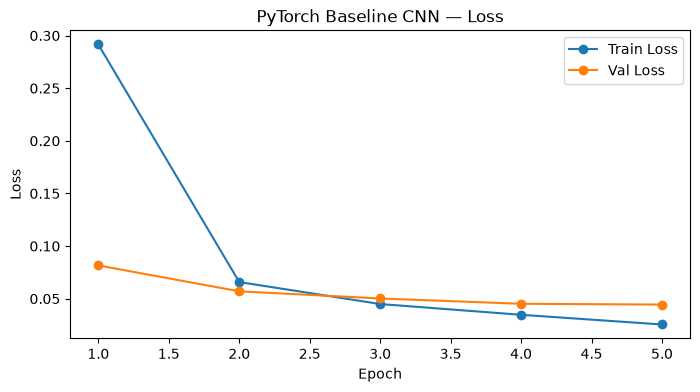

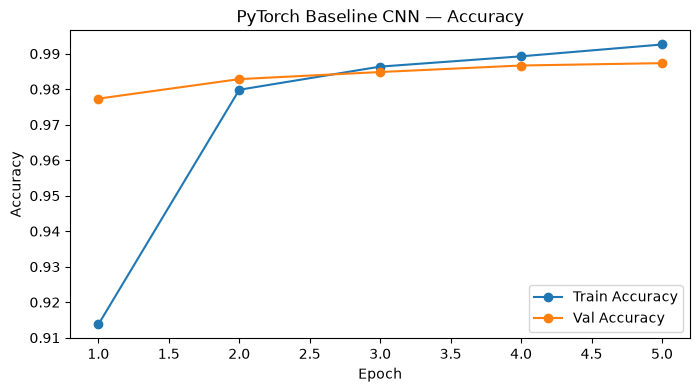

In [28]:
TORCH_EPOCHS = 5
TORCH_LR = 1e-3

torch.manual_seed(SEED)

torch_baseline = TorchBaselineCNN().to(DEVICE)

torch_baseline_history, torch_baseline_time = fit_torch(
    torch_baseline,
    torch_train_loader,
    torch_val_loader,
    epochs=TORCH_EPOCHS,
    learning_rate=TORCH_LR,
)

plot_history_dict(
    torch_baseline_history,
    "PyTorch Baseline CNN",
)

## 11. Train PyTorch Improved

[PyTorch] Epoch 01/5 | train_loss=0.1354 | train_acc=0.9579 | val_loss=0.0453 | val_acc=0.9861
[PyTorch] Epoch 02/5 | train_loss=0.0507 | train_acc=0.9849 | val_loss=0.0627 | val_acc=0.9812
[PyTorch] Epoch 03/5 | train_loss=0.0373 | train_acc=0.9889 | val_loss=0.0396 | val_acc=0.9884
[PyTorch] Epoch 04/5 | train_loss=0.0316 | train_acc=0.9905 | val_loss=0.0492 | val_acc=0.9848
[PyTorch] Epoch 05/5 | train_loss=0.0270 | train_acc=0.9915 | val_loss=0.0416 | val_acc=0.9888


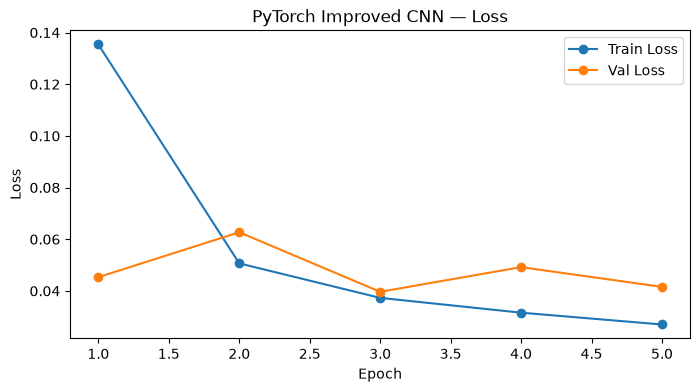

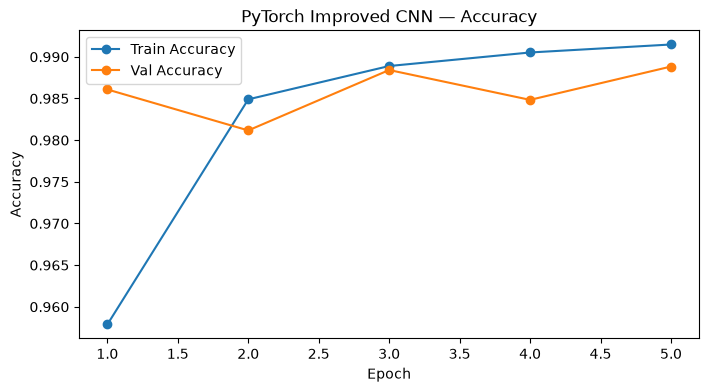

In [29]:
torch.manual_seed(SEED)

torch_improved = TorchImprovedCNN().to(DEVICE)

torch_improved_history, torch_improved_time = fit_torch(
    torch_improved,
    torch_train_loader,
    torch_val_loader,
    epochs=TORCH_EPOCHS,
    learning_rate=TORCH_LR,
)

plot_history_dict(
    torch_improved_history,
    "PyTorch Improved CNN",
)

## 12. Test PyTorch Baseline / Improved

In [30]:
torch_criterion = nn.CrossEntropyLoss()

torch_baseline_test = evaluate_torch(
    torch_baseline,
    torch_test_loader,
    torch_criterion,
    DEVICE,
)

torch_improved_test = evaluate_torch(
    torch_improved,
    torch_test_loader,
    torch_criterion,
    DEVICE,
)

torch_compare_df = pd.DataFrame(
    [
        {
            "Model": "PyTorch Baseline",
            "Loss": torch_baseline_test["loss"],
            "Accuracy": torch_baseline_test["accuracy"],
            "Precision": torch_baseline_test["precision"],
            "Recall": torch_baseline_test["recall"],
            "F1": torch_baseline_test["f1"],
            "Parameters": count_torch_params(torch_baseline),
            "Train Time (s)": torch_baseline_time,
        },
        {
            "Model": "PyTorch Improved",
            "Loss": torch_improved_test["loss"],
            "Accuracy": torch_improved_test["accuracy"],
            "Precision": torch_improved_test["precision"],
            "Recall": torch_improved_test["recall"],
            "F1": torch_improved_test["f1"],
            "Parameters": count_torch_params(torch_improved),
            "Train Time (s)": torch_improved_time,
        },
    ]
)

display(torch_compare_df)

,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,PyTorch Baseline,0.029949,0.9895,0.989602,0.989370,0.989468,421642,111.958099
1,PyTorch Improved,0.034024,0.9899,0.990074,0.989858,0.989930,897354,188.394305


# PHẦN C — TENSORFLOW / KERAS

TensorFlow mặc định dùng image layout:

```text
NHWC = (batch, height, width, channels)
```

trong khi phần NumPy/PyTorch phía trên đang dùng:

```text
NCHW = (batch, channels, height, width)
```

Vì vậy ta transpose dữ liệu trước khi đưa vào Keras.

## 13. Import TensorFlow

In [31]:
import tensorflow as tf

tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU devices: []


## 13.1. Chuyển NCHW → NHWC

In [32]:
X_train_tf = np.transpose(
    X_train,
    (0, 2, 3, 1),
)

X_val_tf = np.transpose(
    X_val,
    (0, 2, 3, 1),
)

X_test_tf = np.transpose(
    X_test,
    (0, 2, 3, 1),
)

print("TF train:", X_train_tf.shape)
print("TF val  :", X_val_tf.shape)
print("TF test :", X_test_tf.shape)

TF train: (48000, 28, 28, 1)
TF val  : (12000, 28, 28, 1)
TF test : (10000, 28, 28, 1)


# 14. TensorFlow Baseline CNN

In [33]:
def build_tf_baseline():
    inputs = tf.keras.Input(shape=(28, 28, 1))

    x = tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        activation="relu",
    )(inputs)

    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu",
    )(x)

    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(x)

    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="TF_Baseline_CNN",
    )


tf_baseline = build_tf_baseline()

tf_baseline.summary()

Model: "TF_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# 15. TensorFlow Improved CNN

In [34]:
def build_tf_improved():
    inputs = tf.keras.Input(shape=(28, 28, 1))

    # Block 1
    x = tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="TF_Improved_CNN",
    )


tf_improved = build_tf_improved()

tf_improved.summary()

Model: "TF_Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,578 (3.42 MB)

 Trainable params: 897,130 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

## 16. Hàm compile/train/evaluate TensorFlow

In [35]:
def compile_tf_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )


def fit_tf_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=5,
    batch_size=128,
    learning_rate=1e-3,
):
    compile_tf_model(
        model,
        learning_rate=learning_rate,
    )

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val,
        ),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )

    elapsed = time.perf_counter() - start_time

    return history, elapsed


def evaluate_tf_model(
    model,
    X,
    y,
    batch_size=128,
):
    # evaluate trả loss + accuracy đã compile.
    test_loss, _ = model.evaluate(
        X,
        y,
        batch_size=batch_size,
        verbose=0,
    )

    logits = model.predict(
        X,
        batch_size=batch_size,
        verbose=0,
    )

    pred = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y,
        pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": float(test_loss),
        "accuracy": accuracy_score(y, pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": np.asarray(y),
        "y_pred": pred,
    }

## 17. Train TensorFlow Baseline

In [36]:
TF_EPOCHS = 5
TF_BATCH_SIZE = 128
TF_LR = 1e-3

tf.random.set_seed(SEED)

tf_baseline = build_tf_baseline()

tf_baseline_history, tf_baseline_time = fit_tf_model(
    tf_baseline,
    X_train_tf,
    y_train,
    X_val_tf,
    y_val,
    epochs=TF_EPOCHS,
    batch_size=TF_BATCH_SIZE,
    learning_rate=TF_LR,
)

print(f"TF Baseline time: {tf_baseline_time:.2f}s")

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9345 - loss: 0.2230 - val_accuracy: 0.9722 - val_loss: 0.0879
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9813 - loss: 0.0602 - val_accuracy: 0.9808 - val_loss: 0.0627
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9883 - loss: 0.0401 - val_accuracy: 0.9864 - val_loss: 0.0463
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9911 - loss: 0.0299 - val_accuracy: 0.9877 - val_loss: 0.0414
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9933 - loss: 0.0234 - val_accuracy: 0.9877 - val_loss: 0.0431
TF Baseline time: 53.79s


## 17.1. Vẽ learning curve TensorFlow

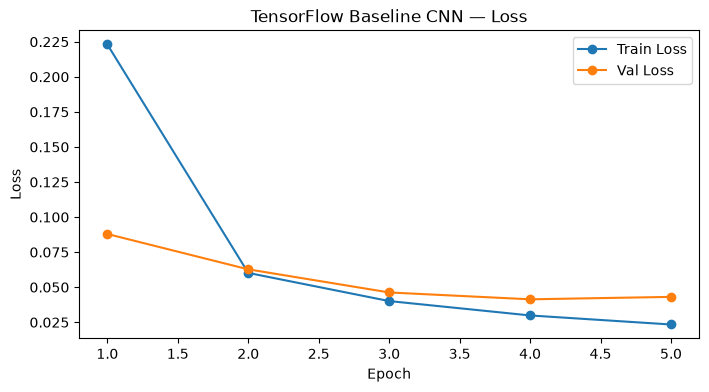

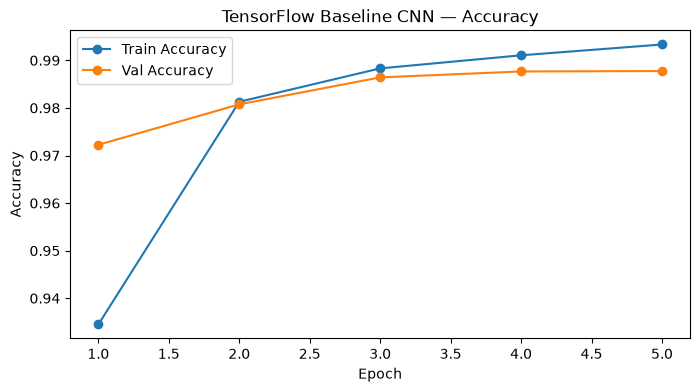

In [37]:
def plot_tf_history(history, title):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        h["loss"],
        marker="o",
        label="Train Loss",
    )
    plt.plot(
        epochs,
        h["val_loss"],
        marker="o",
        label="Val Loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        h["accuracy"],
        marker="o",
        label="Train Accuracy",
    )
    plt.plot(
        epochs,
        h["val_accuracy"],
        marker="o",
        label="Val Accuracy",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.show()


plot_tf_history(
    tf_baseline_history,
    "TensorFlow Baseline CNN",
)

## 18. Train TensorFlow Improved

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.9316 - loss: 0.2346 - val_accuracy: 0.7587 - val_loss: 0.7297
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.9791 - loss: 0.0710 - val_accuracy: 0.9780 - val_loss: 0.0732
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 89ms/step - accuracy: 0.9849 - loss: 0.0512 - val_accuracy: 0.9881 - val_loss: 0.0393
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9873 - loss: 0.0393 - val_accuracy: 0.9872 - val_loss: 0.0487
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 96ms/step - accuracy: 0.9894 - loss: 0.0348 - val_accuracy: 0.9868 - val_loss: 0.0541
TF Improved time: 177.83s


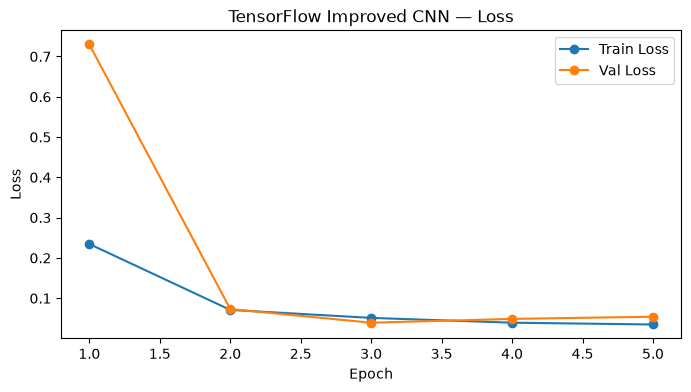

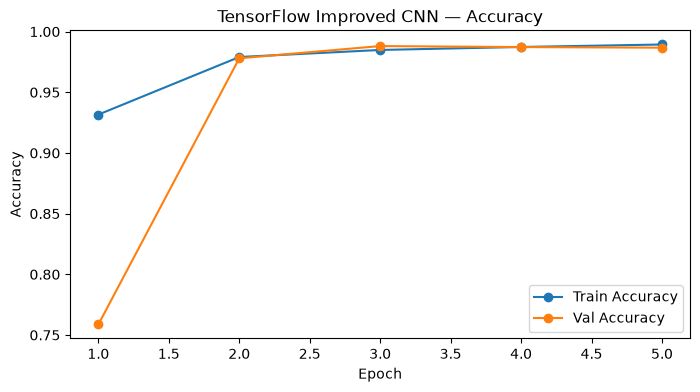

In [38]:
tf.random.set_seed(SEED)

tf_improved = build_tf_improved()

tf_improved_history, tf_improved_time = fit_tf_model(
    tf_improved,
    X_train_tf,
    y_train,
    X_val_tf,
    y_val,
    epochs=TF_EPOCHS,
    batch_size=TF_BATCH_SIZE,
    learning_rate=TF_LR,
)

print(f"TF Improved time: {tf_improved_time:.2f}s")

plot_tf_history(
    tf_improved_history,
    "TensorFlow Improved CNN",
)

## 19. Test TensorFlow Baseline / Improved

In [39]:
tf_baseline_test = evaluate_tf_model(
    tf_baseline,
    X_test_tf,
    y_test,
)

tf_improved_test = evaluate_tf_model(
    tf_improved,
    X_test_tf,
    y_test,
)

tf_compare_df = pd.DataFrame(
    [
        {
            "Model": "TensorFlow Baseline",
            "Loss": tf_baseline_test["loss"],
            "Accuracy": tf_baseline_test["accuracy"],
            "Precision": tf_baseline_test["precision"],
            "Recall": tf_baseline_test["recall"],
            "F1": tf_baseline_test["f1"],
            "Parameters": tf_baseline.count_params(),
            "Train Time (s)": tf_baseline_time,
        },
        {
            "Model": "TensorFlow Improved",
            "Loss": tf_improved_test["loss"],
            "Accuracy": tf_improved_test["accuracy"],
            "Precision": tf_improved_test["precision"],
            "Recall": tf_improved_test["recall"],
            "F1": tf_improved_test["f1"],
            "Parameters": tf_improved.count_params(),
            "Train Time (s)": tf_improved_time,
        },
    ]
)

display(tf_compare_df)

,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,TensorFlow Baseline,0.031390,0.989,0.988913,0.988976,0.988924,421642,53.787403
1,TensorFlow Improved,0.043085,0.988,0.988282,0.988018,0.988060,897578,177.826662


# PHẦN D — TỔNG HỢP KẾT QUẢ

## 20. Bảng tổng hợp tất cả model

In [40]:
all_results = pd.DataFrame(
    [
        {
            "Implementation": "NumPy",
            "Model": "Scratch CNN",
            "Training Samples": len(X_train_s),
            "Test Samples": len(X_test_s),
            "Loss": scratch_test["loss"],
            "Accuracy": scratch_test["accuracy"],
            "Precision": scratch_test["precision"],
            "Recall": scratch_test["recall"],
            "F1": scratch_test["f1"],
            "Parameters": scratch_model.param_count(),
            "Train Time (s)": scratch_train_time,
        },
        {
            "Implementation": "PyTorch",
            "Model": "Baseline CNN",
            "Training Samples": len(X_train),
            "Test Samples": len(X_test),
            "Loss": torch_baseline_test["loss"],
            "Accuracy": torch_baseline_test["accuracy"],
            "Precision": torch_baseline_test["precision"],
            "Recall": torch_baseline_test["recall"],
            "F1": torch_baseline_test["f1"],
            "Parameters": count_torch_params(torch_baseline),
            "Train Time (s)": torch_baseline_time,
        },
        {
            "Implementation": "PyTorch",
            "Model": "Improved CNN",
            "Training Samples": len(X_train),
            "Test Samples": len(X_test),
            "Loss": torch_improved_test["loss"],
            "Accuracy": torch_improved_test["accuracy"],
            "Precision": torch_improved_test["precision"],
            "Recall": torch_improved_test["recall"],
            "F1": torch_improved_test["f1"],
            "Parameters": count_torch_params(torch_improved),
            "Train Time (s)": torch_improved_time,
        },
        {
            "Implementation": "TensorFlow",
            "Model": "Baseline CNN",
            "Training Samples": len(X_train),
            "Test Samples": len(X_test),
            "Loss": tf_baseline_test["loss"],
            "Accuracy": tf_baseline_test["accuracy"],
            "Precision": tf_baseline_test["precision"],
            "Recall": tf_baseline_test["recall"],
            "F1": tf_baseline_test["f1"],
            "Parameters": tf_baseline.count_params(),
            "Train Time (s)": tf_baseline_time,
        },
        {
            "Implementation": "TensorFlow",
            "Model": "Improved CNN",
            "Training Samples": len(X_train),
            "Test Samples": len(X_test),
            "Loss": tf_improved_test["loss"],
            "Accuracy": tf_improved_test["accuracy"],
            "Precision": tf_improved_test["precision"],
            "Recall": tf_improved_test["recall"],
            "F1": tf_improved_test["f1"],
            "Parameters": tf_improved.count_params(),
            "Train Time (s)": tf_improved_time,
        },
    ]
)

display(
    all_results.style.format(
        {
            "Loss": "{:.4f}",
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Parameters": "{:,.0f}",
            "Train Time (s)": "{:.2f}",
        }
    )
)

,Implementation,Model,Training Samples,Test Samples,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,NumPy,Scratch CNN,5000,2000,0.5226,0.8275,0.8445,0.8291,0.8283,"32,618",27.30
1,PyTorch,Baseline CNN,48000,10000,0.0299,0.9895,0.9896,0.9894,0.9895,"421,642",111.96
2,PyTorch,Improved CNN,48000,10000,0.0340,0.9899,0.9901,0.9899,0.9899,"897,354",188.39
3,TensorFlow,Baseline CNN,48000,10000,0.0314,0.9890,0.9889,0.9890,0.9889,"421,642",53.79
4,TensorFlow,Improved CNN,48000,10000,0.0431,0.9880,0.9883,0.9880,0.9881,"897,578",177.83


### Cách đọc bảng

Không nên chỉ nhìn Accuracy.

Hãy so sánh thêm:

- `F1`
- `Loss`
- số `Parameters`
- `Training Time`
- số mẫu train

> Nếu `FAST_SCRATCH=True`, NumPy Scratch dùng ít dữ liệu hơn.  
> Khi đó **không nên kết luận framework nào tốt hơn chỉ từ Accuracy**.  
> Mục tiêu chính của Scratch là chứng minh bạn hiểu và tự cài được thuật toán bên trong CNN.

## 21. So sánh Accuracy bằng biểu đồ

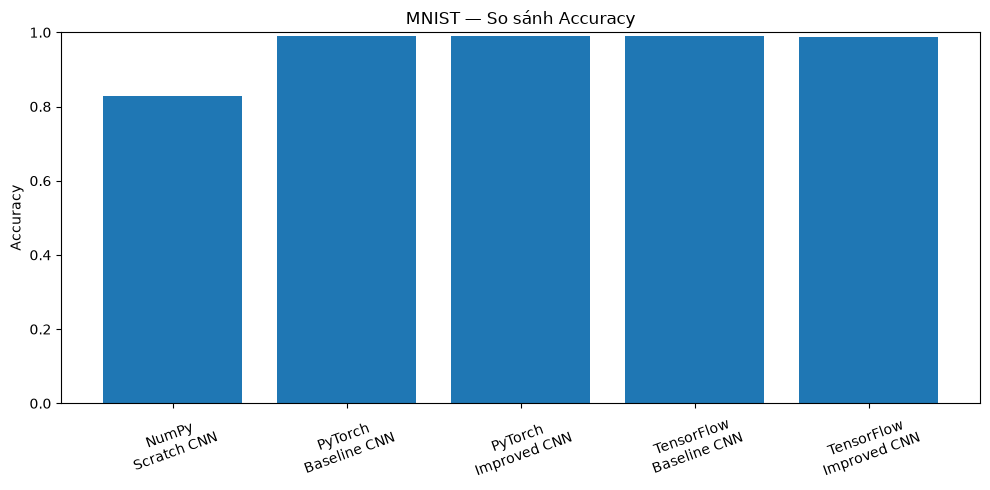

In [41]:
labels = all_results["Implementation"] + "\n" + all_results["Model"]

plt.figure(figsize=(10, 5))
plt.bar(
    labels,
    all_results["Accuracy"],
)

plt.ylabel("Accuracy")
plt.title("MNIST — So sánh Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 22. Confusion Matrix — PyTorch Baseline

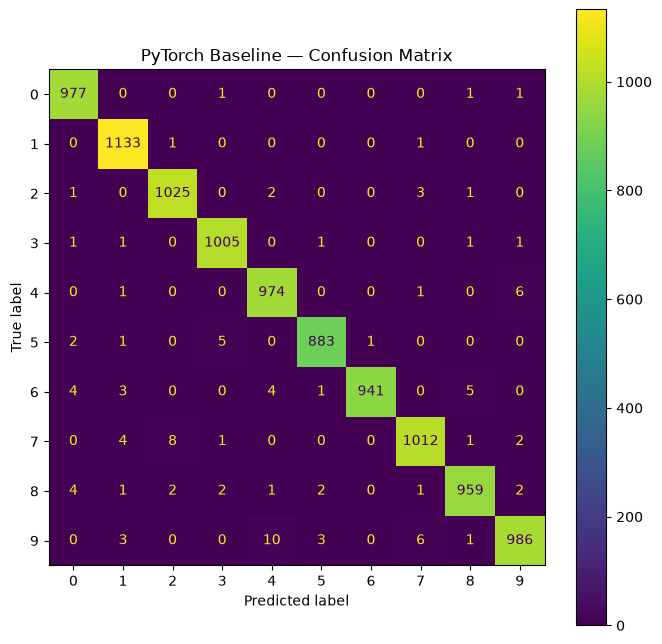

In [42]:
cm = confusion_matrix(
    torch_baseline_test["y_true"],
    torch_baseline_test["y_pred"],
)

fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10)),
).plot(
    ax=ax,
    values_format="d",
)

plt.title("PyTorch Baseline — Confusion Matrix")
plt.show()

## 23. Confusion Matrix — PyTorch Improved

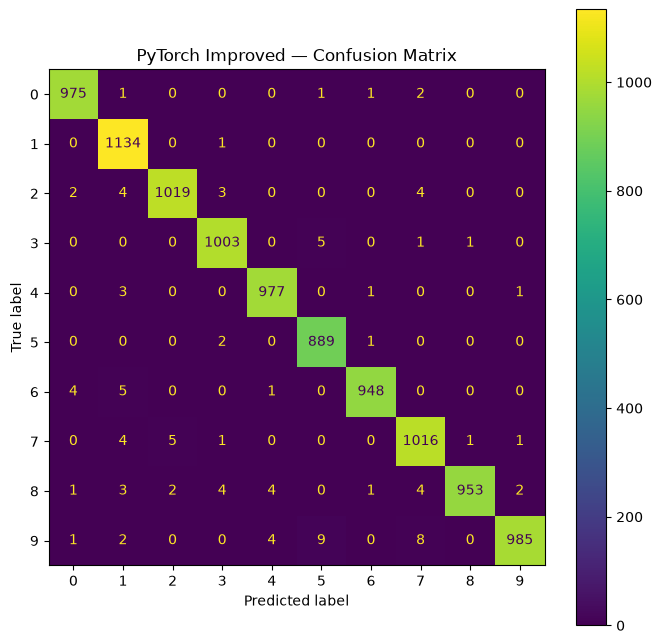

In [43]:
cm = confusion_matrix(
    torch_improved_test["y_true"],
    torch_improved_test["y_pred"],
)

fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10)),
).plot(
    ax=ax,
    values_format="d",
)

plt.title("PyTorch Improved — Confusion Matrix")
plt.show()

## 24. Classification Report — Improved CNN

In [44]:
print("PYTORCH IMPROVED")
print(
    classification_report(
        torch_improved_test["y_true"],
        torch_improved_test["y_pred"],
        digits=4,
        zero_division=0,
    )
)

print("\n" + "=" * 70 + "\n")

print("TENSORFLOW IMPROVED")
print(
    classification_report(
        tf_improved_test["y_true"],
        tf_improved_test["y_pred"],
        digits=4,
        zero_division=0,
    )
)

PYTORCH IMPROVED
              precision    recall  f1-score   support

           0     0.9919    0.9949    0.9934       980
           1     0.9810    0.9991    0.9900      1135
           2     0.9932    0.9874    0.9903      1032
           3     0.9892    0.9931    0.9911      1010
           4     0.9909    0.9949    0.9929       982
           5     0.9834    0.9966    0.9900       892
           6     0.9958    0.9896    0.9927       958
           7     0.9816    0.9883    0.9850      1028
           8     0.9979    0.9784    0.9881       974
           9     0.9960    0.9762    0.9860      1009

    accuracy                         0.9899     10000
   macro avg     0.9901    0.9899    0.9899     10000
weighted avg     0.9900    0.9899    0.9899     10000



TENSORFLOW IMPROVED
              precision    recall  f1-score   support

           0     0.9959    0.9949    0.9954       980
           1     0.9895    0.9965    0.9930      1135
           2     0.9990    0.9671    0.

## 25. Xem prediction sai của PyTorch Improved

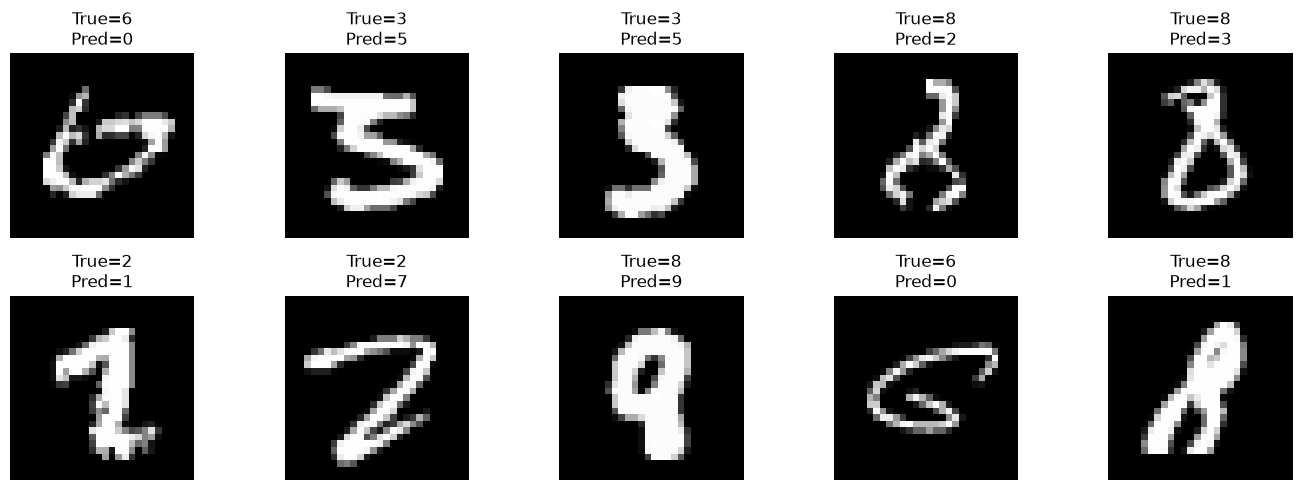

In [45]:
@torch.no_grad()
def collect_torch_mistakes(
    model,
    loader,
    device,
    max_items=10,
):
    model.eval()

    mistakes = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        pred = logits.argmax(dim=1)

        wrong = pred != labels

        wrong_images = images[wrong].cpu()
        wrong_true = labels[wrong].cpu()
        wrong_pred = pred[wrong].cpu()

        for image, true_label, pred_label in zip(
            wrong_images,
            wrong_true,
            wrong_pred,
        ):
            mistakes.append(
                (
                    image.squeeze(0).numpy(),
                    int(true_label),
                    int(pred_label),
                )
            )

            if len(mistakes) >= max_items:
                return mistakes

    return mistakes


mistakes = collect_torch_mistakes(
    torch_improved,
    torch_test_loader,
    DEVICE,
    max_items=10,
)

plt.figure(figsize=(14, 5))

for i, (
    image,
    true_label,
    pred_label,
) in enumerate(mistakes, start=1):
    plt.subplot(2, 5, i)
    plt.imshow(image, cmap="gray")
    plt.title(f"True={true_label}\nPred={pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 26. Lưu model và kết quả

In [46]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# PyTorch
torch.save(
    torch_baseline.state_dict(),
    OUTPUT_DIR / "mnist_torch_baseline.pt",
)

torch.save(
    torch_improved.state_dict(),
    OUTPUT_DIR / "mnist_torch_improved.pt",
)

# TensorFlow
tf_baseline.save(OUTPUT_DIR / "mnist_tf_baseline.keras")

tf_improved.save(OUTPUT_DIR / "mnist_tf_improved.keras")

# Bảng metric
all_results.to_csv(
    OUTPUT_DIR / "mnist_all_results.csv",
    index=False,
)

print("Đã lưu vào:", OUTPUT_DIR.resolve())

Đã lưu vào: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\a04\notebook\MNist\outputs


# 27. Kết luận / nội dung có thể đưa vào báo cáo

Sau khi chạy notebook, bạn có đủ dữ liệu để viết phần MNIST của A04.

## 27.1. Dataset

Ghi:

- kích thước train / validation / test;
- ảnh grayscale `28×28`;
- 10 class từ `0 → 9`;
- normalize `[0,255] → [0,1]`.

## 27.2. CNN From Scratch

Giải thích bạn tự code:

```text
Conv2D
ReLU
MaxPool
Flatten
Dense
Softmax Cross Entropy
Backpropagation
SGD
```

Flow:

```text
forward
→ loss
→ backward
→ update
```

## 27.3. Discover / Baseline CNN

Baseline:

```text
Input
→ Conv32
→ ReLU
→ Pool
→ Conv64
→ ReLU
→ Pool
→ Dense128
→ Output10
```

Đây là **mốc ban đầu**.

## 27.4. Improved CNN

Cải tiến:

```text
Baseline
+ BatchNorm
+ Conv block 128 channels
+ Dropout
```

Sau đó train lại và so với Baseline.

## 27.5. Ba cách triển khai

Bạn đã thể hiện:

```text
NumPy From Scratch
PyTorch
TensorFlow / Keras
```

## 27.6. Output nên chụp/đưa vào báo cáo

1. Ảnh mẫu MNIST.
2. Phân bố class.
3. Shape qua các layer Scratch.
4. Shape qua các layer PyTorch.
5. Model summary TensorFlow.
6. Loss curve.
7. Accuracy curve.
8. Bảng:
   - Loss
   - Accuracy
   - Precision
   - Recall
   - F1
   - Parameters
   - Training Time
9. Confusion Matrix.
10. Một số ảnh prediction sai.
11. Nhận xét Baseline vs Improved.
12. Nhận xét NumPy vs framework.

---

# Flow tổng thể của notebook

```text
                    MNIST
                      │
               Load / Preprocess
                      │
        ┌─────────────┼─────────────┐
        │             │             │
      NumPy         PyTorch      TensorFlow
        │             │             │
    Scratch CNN   Baseline CNN   Baseline CNN
        │             │             │
        │         Improved CNN  Improved CNN
        │             │             │
        └─────────────┼─────────────┘
                      │
                  Evaluation
                      │
       Accuracy / F1 / Loss / Time
                      │
             Confusion Matrix
                      │
                  Conclusion
```